In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math


In [20]:
# Example file for testing / developing a quick understanding
filename = "../datasets/MBTA-Bus-Arrival-Departure-Times_2024-12.csv"
df = pd.read_csv(filename, low_memory=False)

In [21]:
# Calculate delay for each line
df['time_difference'] = pd.to_datetime(df['actual']) - pd.to_datetime(df['scheduled'])
df['delay_seconds'] = df['time_difference'].dt.total_seconds()
df['delay_headway'] = df['headway'] - df['scheduled_headway']

In [22]:
# Filter outliers that skew averages (delays over 60 minutes)
df = df[(df['delay_seconds'] >= -3600) & (df['delay_seconds'] <= 3600)]

In [23]:
df.dropna(subset=['delay_seconds'], inplace=True)

In [49]:
print(df['route_id'].unique())


['01' '08' '09' '10' '100' '101' '104' '105' '106' '108' '109' '11' '110'
 '111' '112' '116' '117' '119' '120' '134' '137' '15' '16' '17' '171'
 '191' '194' '201' '21' '210' '211' '215' '216' '22' '220' '222' '225'
 '23' '230' '236' '238' '24' '240' '26' '28' '30' '31' '32' '34' '34E'
 '35' '350' '36' '39' '40' '41' '42' '426' '429' '43' '435' '44' '441'
 '442' '45' '450' '455' '47' '55' '57' '59' '60' '61' '64' '66' '69' '70'
 '71' '73' '743' '746_' '75' '77' '78' '80' '83' '86' '87' '88' '89' '90'
 '91' '93' '94' '95' '96' '97' '99' 'SL1' 'SL2' 'SL4' 'SL5' '04' '07'
 '114' '121' '131' '132' '14' '18' '19' '192' '193' '202' '217' '226'
 '245' '29' '33' '351' '354' '37' '38' '411' '424' '428' '430' '436' '439'
 '451' '456' '50' '501' '504' '505' '51' '52' '553' '554' '556' '558' '62'
 '65' '67' '68' '74' '76' '85' '92' 'CT2' 'CT3' '600' 'rad']


In [51]:
# Only key bus routes
filtered_route_df = df[(df['route_id'].isin(["01", "15", "22", "23", "28", "32",
                                            "39", "57", "66", "71", "73", "77", "111", "116", "117"]))]

In [52]:
len(filtered_route_df)

684314

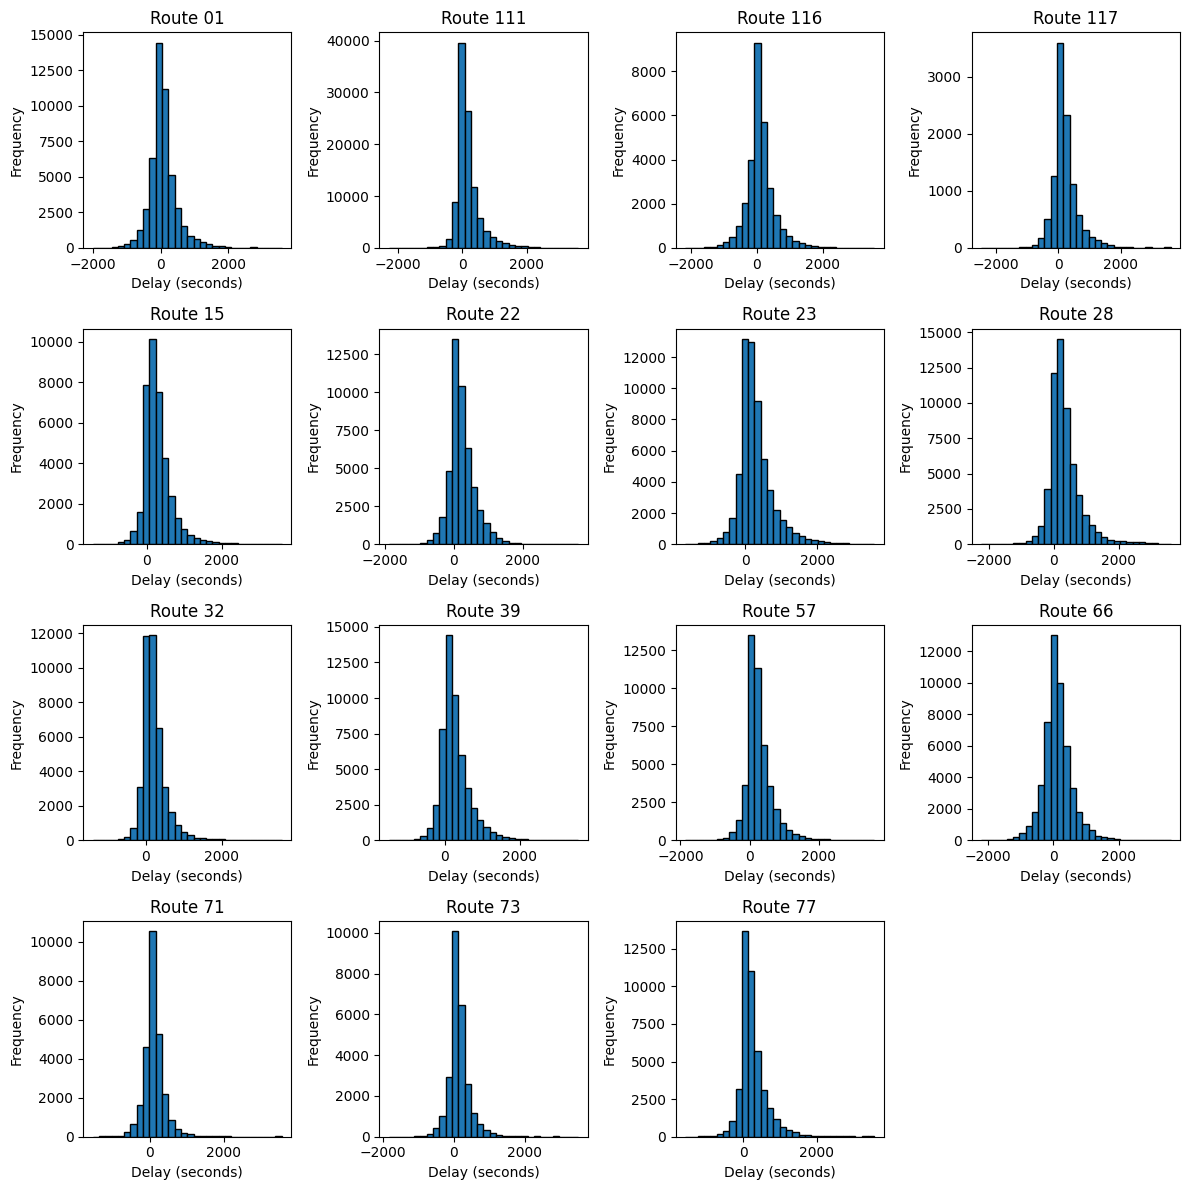

In [53]:
bins      = 30            # histogram granularity
cols      = 4             # plots per row
figscale  = 3             # size multiplier (3 → ~3″×3″ per subplot)
# --------------------------------------

routes = sorted(filtered_route_df['route_id'].unique())
n      = len(routes)
rows   = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * figscale, rows * figscale), squeeze=False)

for i, route in enumerate(routes):
    r, c = divmod(i, cols)
    ax   = axes[r][c]

    # plot histogram for this route
    ax.hist(filtered_route_df.loc[filtered_route_df['route_id'] == route, 'delay_seconds'],
            bins=bins, edgecolor='black')
    ax.set_title(f'Route {route}')
    ax.set_xlabel('Delay (seconds)')
    ax.set_ylabel('Frequency')

# turn off any empty subplot frames (when routes % cols ≠ 0)
for j in range(i + 1, rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# Different metrics:
# - Average delay per route
# - Median delay per route
# - Average positive delay
# - Percent of buses arriving on time (within 5 minutes)
# - Percent of buses arriving within 10 minutes
# - 95th percentile of delays (and positive delays)
# - Percent of buses arriving greater than 5 minutes late
# - Percent of buses arriving greater than 10 minutes late

In [55]:
grouped = filtered_route_df.groupby('route_id')

# Define custom metrics
route_metrics = pd.DataFrame({
    'avg_delay_min': grouped['delay_seconds'].mean(),
    'median_delay_min': grouped['delay_seconds'].median(),
    'avg_positive_delay_min': grouped.apply(lambda x: x[x['delay_seconds'] > 0]['delay_seconds'].mean()),
    'percent_on_time_5min': grouped.apply(lambda x: (x['delay_seconds'].abs() <= 300).mean() * 100),
    'percent_on_time_10min': grouped.apply(lambda x: (x['delay_seconds'].abs() <= 600).mean() * 100),
    '95th_percentile_delay_min': grouped['delay_seconds'].quantile(0.95),
    '95th_percentile_pos_delay_min': grouped.apply(lambda x: x[x['delay_seconds'] > 0]['delay_seconds'].quantile(0.95)),
    'percent_late_gt_5min': grouped.apply(lambda x: (x['delay_seconds'] > 300).mean() * 100),
    'percent_late_gt_10min': grouped.apply(lambda x: (x['delay_seconds'] > 600).mean() * 100)
})

# Optional: round for cleaner display
route_metrics = route_metrics.round(2)

# Show or save
print(route_metrics)

C:\Users\Michael\AppData\Local\Temp\ipykernel_23276\983293078.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'avg_positive_delay_min': grouped.apply(lambda x: x[x['delay_seconds'] > 0]['delay_seconds'].mean()),
C:\Users\Michael\AppData\Local\Temp\ipykernel_23276\983293078.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'percent_on_time_5min': grouped.apply(lambda x: (x['delay_seconds'].abs() <= 300

          avg_delay_min  median_delay_min  avg_positive_delay_min  \
route_id                                                            
01                77.40              27.0                  316.91   
111              180.25              80.0                  320.57   
116              118.69              77.0                  322.91   
117              216.00             142.0                  348.28   
15               281.93             206.0                  360.36   
22               237.04             165.0                  360.18   
23               293.02             189.0                  439.86   
28               343.36             239.0                  462.42   
32               227.14             158.0                  303.07   
39               282.33             191.0                  384.48   
57               265.34             182.0                  360.07   
66               127.50              83.0                  374.20   
71               115.97           

C:\Users\Michael\AppData\Local\Temp\ipykernel_23276\983293078.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'percent_late_gt_10min': grouped.apply(lambda x: (x['delay_seconds'] > 600).mean() * 100)


In [56]:
route_metrics.to_csv("route_metrics.csv", index=True)